In [3]:
# Connect Python to MySQL
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="nishu123",
    database="phonepe"
)

In [4]:
# Load Data
query = "SELECT * FROM aggregated_transaction"
df = pd.read_sql(query, conn)

print(df.head())

C:\Users\abc\AppData\Local\Temp\ipykernel_4300\2263741676.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


                       state  year  quarter                      type  count  \
0  andaman-&-nicobar-islands  2018        1  Recharge & bill payments   4200   
1  andaman-&-nicobar-islands  2018        1     Peer-to-peer payments   1871   
2  andaman-&-nicobar-islands  2018        1         Merchant payments    298   
3  andaman-&-nicobar-islands  2018        1        Financial Services     33   
4  andaman-&-nicobar-islands  2018        1                    Others    256   

         amount  
0  1.845307e+06  
1  1.213866e+07  
2  4.525072e+05  
3  1.060142e+04  
4  1.846899e+05  


In [5]:
# Import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

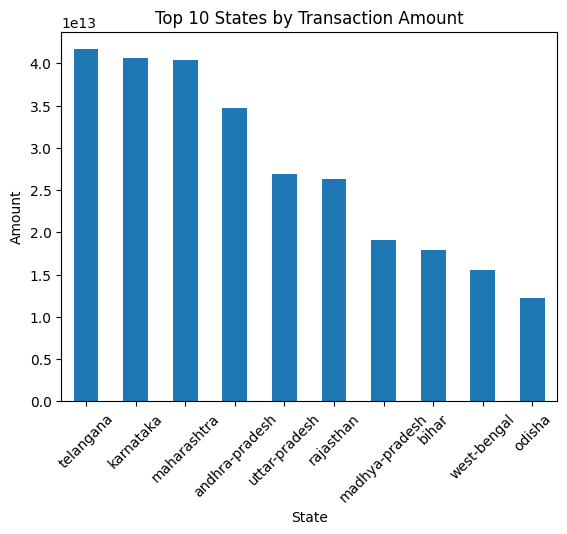

In [6]:
# VISUALIZATION 1: Top 10 States (Bar Chart)
top_states = df.groupby("state")["amount"].sum().sort_values(ascending=False).head(10)

top_states.plot(kind="bar")
plt.title("Top 10 States by Transaction Amount")
plt.xlabel("State")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

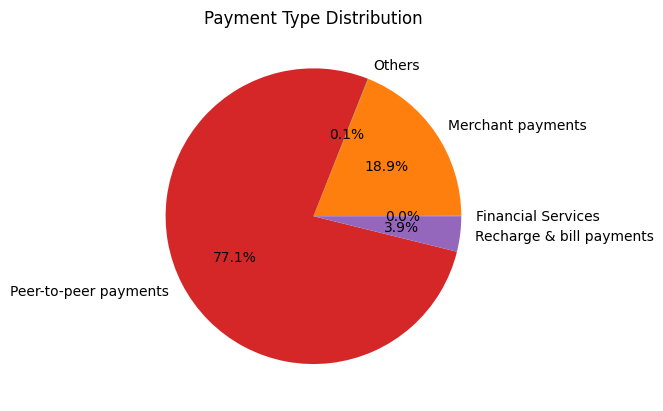

In [7]:
# VISUALIZATION 2: Payment Type Distribution (Pie Chart)
payment = df.groupby("type")["amount"].sum()

payment.plot(kind="pie", autopct='%1.1f%%')
plt.title("Payment Type Distribution")
plt.ylabel("")
plt.show()

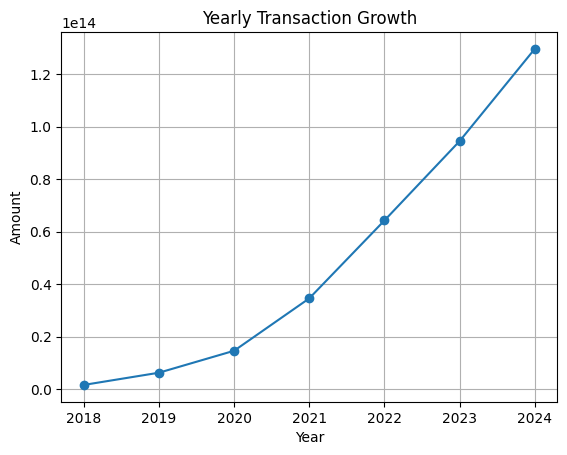

In [8]:
# VISUALIZATION 3: Year-wise Trend (Line Chart)
yearly = df.groupby("year")["amount"].sum()

plt.plot(yearly.index, yearly.values, marker='o')
plt.title("Yearly Transaction Growth")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.grid()
plt.show()

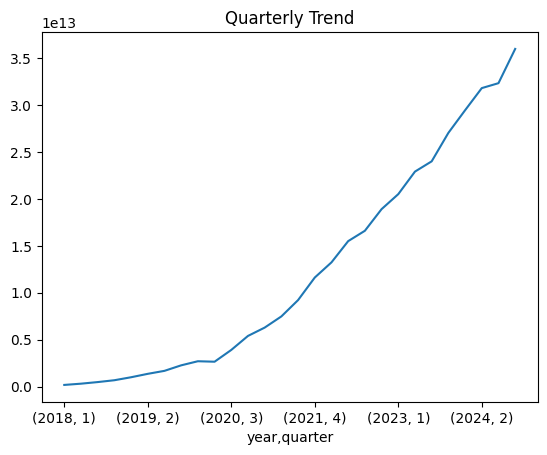

In [9]:
# VISUALIZATION 4: Quarterly Trend
quarterly = df.groupby(["year","quarter"])["amount"].sum()

quarterly.plot()
plt.title("Quarterly Trend")
plt.show()

C:\Users\abc\AppData\Local\Temp\ipykernel_4300\280014871.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql("SELECT * FROM map_transaction", conn)


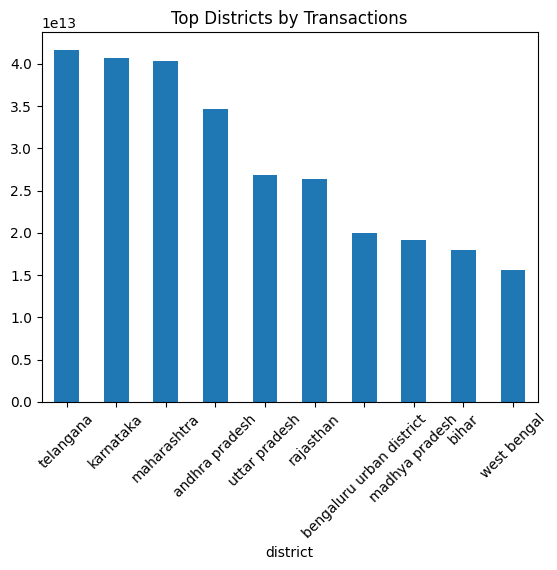

(21612, 6)
   state  year  quarter        district     count        amount
0  india  2018        1      puducherry    104212  1.658260e+08
1  india  2018        1      tamil nadu   6726622  1.126156e+10
2  india  2018        1   uttar pradesh  12537805  1.393997e+10
3  india  2018        1  madhya pradesh   8025395  8.681603e+09
4  india  2018        1  andhra pradesh   9039585  1.199628e+10
state        object
year          int64
quarter       int64
district     object
count         int64
amount      float64
dtype: object


In [11]:
# # VISUALIZATION 5: District Analysis (Map Table)
df_map = pd.read_sql("SELECT * FROM map_transaction", conn)

top_districts = df_map.groupby("district")["amount"].sum().sort_values(ascending=False).head(10)

top_districts.plot(kind="bar")
plt.title("Top Districts by Transactions")
plt.xticks(rotation=45)
plt.show()
print(df_map.shape)
print(df_map.head())
print(df_map.dtypes)

C:\Users\abc\AppData\Local\Temp\ipykernel_4300\940031360.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql("SELECT * FROM map_transaction", conn)


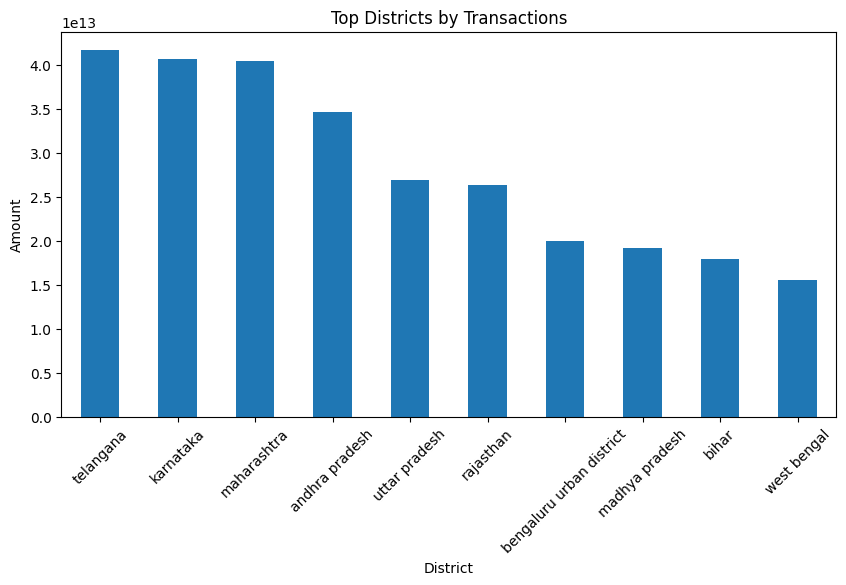

In [12]:
# Convert to numeric (REQUIRED)
df_map["amount"] = pd.to_numeric(df_map["amount"], errors="coerce")
# Remove null values
df_map = df_map.dropna(subset=["amount"])

df_map = pd.read_sql("SELECT * FROM map_transaction", conn)

# Convert datatype
df_map["amount"] = pd.to_numeric(df_map["amount"], errors="coerce")

# Remove invalid rows
df_map = df_map.dropna(subset=["amount"])

# Check if empty
if df_map.empty:
    print("No data available")
else:
    top_districts = df_map.groupby("district")["amount"].sum().sort_values(ascending=False).head(10)

    if top_districts.empty:
        print("No grouped data available")
    else:
        top_districts.plot(kind="bar", figsize=(10,5))
        plt.title("Top Districts by Transactions")
        plt.xlabel("District")
        plt.ylabel("Amount")
        plt.xticks(rotation=45)
        plt.show()

C:\Users\abc\AppData\Local\Temp\ipykernel_4300\1513375920.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_user = pd.read_sql("SELECT * FROM aggregated_user", conn)


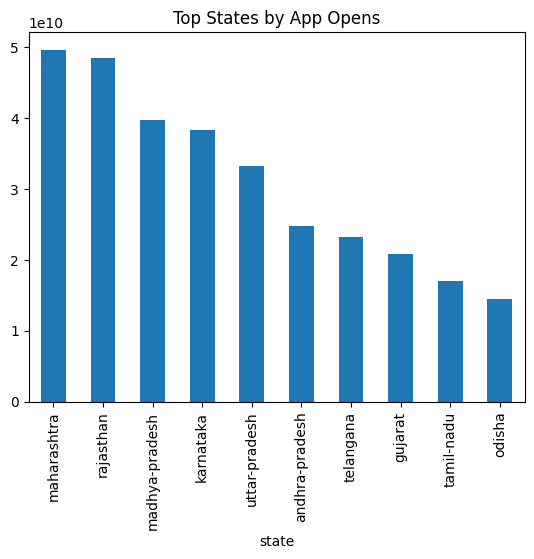

In [13]:
# VISUALIZATION 6: User Engagement
df_user = pd.read_sql("SELECT * FROM aggregated_user", conn)

engagement = df_user.groupby("state")["appOpens"].sum().sort_values(ascending=False).head(10)

engagement.plot(kind="bar")
plt.title("Top States by App Opens")
plt.show()

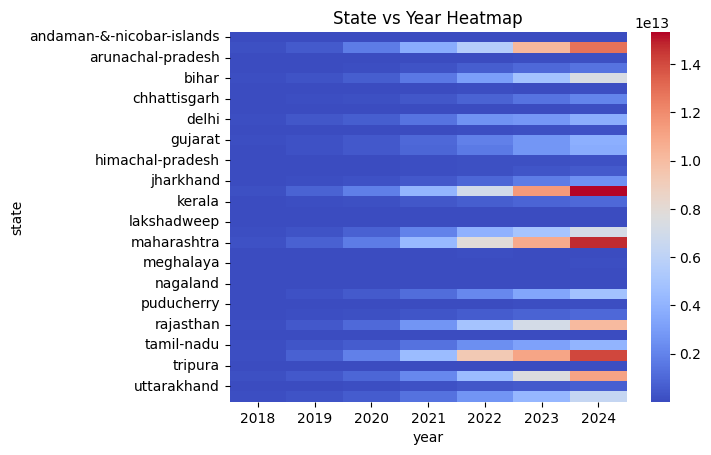

In [ ]:
# VISUALIZATION 7: Heatmap
pivot = df.pivot_table(values="amount", index="state", columns="year", aggfunc="sum")

sns.heatmap(pivot, cmap="coolwarm")
plt.title("State vs Year Heatmap")
plt.show()